In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import liana as li
import scanpy as sc
import numpy as np
import pandas as pd
import pickle

from tqdm import tqdm
from scipy.stats import zscore, spearmanr
from calculate_quiescence_score import score_quiescence
from plotnine import theme, element_text, element_blank, scale_x_discrete, scale_color_gradientn

In [4]:
sc.settings.set_figure_params(frameon=False)
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.join(os.path.expanduser("~"), "BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
# Read in
adata = sc.read_h5ad(data_dir + "adata_with_signatures_and_hotspots.h5ad")

In [7]:
adata.obs.columns.tolist()

['in_tissue',
 'array_row',
 'array_col',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'batch',
 'total_counts_mt',
 'log1p_total_counts_mt',
 'pct_counts_mt',
 'tumour_cells',
 'B cells Memory',
 'B cells Naive',
 'CAFs MSC iCAF-like',
 'CAFs myCAF-like',
 'Cancer Basal SC',
 'Cancer Cycling',
 'Cancer Her2 SC',
 'Cancer LumA SC',
 'Cancer LumB SC',
 'Cycling PVL',
 'Cycling T-cells',
 'Cycling_Myeloid',
 'DCs',
 'Endothelial ACKR1',
 'Endothelial CXCL12',
 'Endothelial Lymphatic LYVE1',
 'Endothelial RGS5',
 'Luminal Progenitors',
 'Macrophage',
 'Mature Luminal',
 'Monocyte',
 'Myoepithelial',
 'NK cells',
 'NKT cells',
 'PVL Differentiated',
 'PVL Immature',
 'Plasmablasts',
 'T cells CD4+',
 'T cells CD8+',
 'CAFs MSC iCAF-like s1',
 'CAFs MSC iCAF-like s2',
 'CAFs Transitioning s3',
 'CAFs myCAF like s4',
 'CAFs myCAF like s5',
 'Cancer Basal SC_0',
 'Cancer Basal SC_1',
 'Cancer Basal SC_2',
 'Cancer Cycling_0',
 'Cancer Cycling_1',


In [8]:
hotspot_col = "CAFs myCAF like s4_hot"
hotspot_label = "CAFs myCAF like s4_hot"
g0_col = "G0_arrested_hot"
g0_label = "G0_arrested_hot"

# Sanity checks
for col in [hotspot_col, g0_col]:
    if col not in adata.obs.columns:
        raise KeyError(f"{col} not found in adata.obs")

# Initialise cell_type
adata.obs["cell_type"] = "Other"
adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Add required categories
adata.obs["cell_type"] = adata.obs["cell_type"].cat.add_categories(
    [hotspot_label, g0_label]
)

# Assign CXCL10 macrophage hotspot cells
cxcl10_mask = adata.obs[hotspot_col].fillna(False).astype(bool)
adata.obs.loc[cxcl10_mask, "cell_type"] = hotspot_label

# Assign G0-arrested-hot tumour cells directly
g0_mask = adata.obs[g0_col].fillna(False).astype(bool)
adata.obs.loc[g0_mask, "cell_type"] = g0_label

# Clean up categories
adata.obs["cell_type"] = adata.obs["cell_type"].cat.remove_unused_categories()

print("Final categories:", adata.obs["cell_type"].cat.categories.tolist())

# Subset AnnData
keep_mask = adata.obs["cell_type"].isin([hotspot_label, g0_label])
adata = adata[keep_mask].copy()


Final categories: ['Other', 'CAFs myCAF like s4_hot', 'G0_arrested_hot']


In [9]:
# Verify final cell type distribution
print(adata.obs["cell_type"].value_counts())

cell_type
CAFs myCAF like s4_hot    1981
G0_arrested_hot            836
Name: count, dtype: int64


In [10]:
# subset cell types of interest
cell_type = ["G0_arrested_hot", "CAFs myCAF like s4_hot"]
adata = adata[adata.obs["cell_type"].isin(cell_type)].copy()

In [11]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 8 genes that are detected in less than 1 cells
normalizing counts per cell
    finished (0:00:00)


In [12]:
li.mt.rank_aggregate(
    adata,
    groupby="cell_type",
    resource_name="consensus",
    aggregate_method="rra",
    expr_prop=0.1,
    use_raw=False,
    de_method="wilcoxon",
    return_all_lrs=False,
    verbose=True,
    n_jobs=32,
)

Using resource `consensus`.
Using `.X`!
0.24 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 2817 samples and 1356 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:03<00:00, 253.84it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


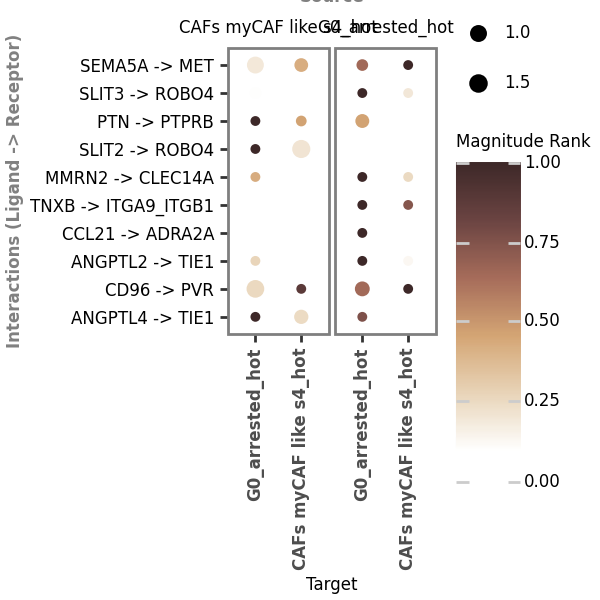

In [16]:
figure = (
    li.pl.dotplot(
        adata=adata,
        colour="magnitude_rank",
        size="specificity_rank",
        inverse_colour=True,
        inverse_size=True,
        source_labels=["CAFs myCAF like s4_hot", "G0_arrested_hot"],
        target_labels=["G0_arrested_hot", "CAFs myCAF like s4_hot"],
        filter_fun=lambda x: x["specificity_rank"] <= 0.2 and x["magnitude_rank"] > 0.5,
        orderby="magnitude_rank",
        orderby_ascending=True,
        top_n=10,
        figure_size=(3, 3),
        size_range=(1, 3),
    )
    + theme(
        text=element_text(size=6),
        panel_grid=element_blank(),
        strip_background=element_blank(),
    )
    + scale_x_discrete(limits=["G0_arrested_hot", "CAFs myCAF like s4_hot"])
    + scale_color_gradientn(
        colors=[
            "#ffffff",
            "#ffffff",
            "#ffffff",  # off-white cream
            "#e8d4b8",  # beige
            "#d4a574",  # tan
            "#a66c5a",  # terracotta
            "#6b4442",  # muted maroon
            "#3d2828",
        ],  # dark brown
        values=[0, 0.1, 0.1, 0.28, 0.46, 0.64, 0.82, 1],
        limits=(0, 1),
        name="Magnitude Rank",
    )
)

figure.save(figure_dir + "spatial_liana_dotplot_caf.pdf")
figure